In [ ]:
import pandas as pd
from scipy.stats import wilcoxon, mannwhitneyu

# Load data
df = pd.read_csv("../results/fully_replicate/itpc_results/itpc_long.csv")

# Average repeated rows within participant/condition/group
# Add frequency_name/channel here if you want to test them separately
agg = df.groupby(["participant", "language_group", "rhythm_condition"], as_index=False)[
    "itpc"
].mean()

# Wide format: one row per participant
wide = agg.pivot(
    index=["participant", "language_group"], columns="rhythm_condition", values="itpc"
).reset_index()

# Check your actual condition names
conditions = list(agg["rhythm_condition"].dropna().unique())
print("Rhythm conditions:", conditions)

cond1, cond2 = conditions[:2]

# -----------------------------
# 1. Main effect: rhythm condition
# paired Wilcoxon across participants
# -----------------------------
paired = wide[[cond1, cond2]].dropna()

stat, p =   (paired[cond1], paired[cond2])

print("\nRhythm condition effect")
print(f"{cond1} vs {cond2}")
print(f"Wilcoxon statistic = {stat:.3f}, p = {p:.4g}")

# -----------------------------
# 2. Compute within-person difference
# -----------------------------
wide["delta_itpc"] = wide[cond2] - wide[cond1]

# -----------------------------
# 3. Does rhythm effect differ by language group?
# Mann–Whitney on participant-level differences
# -----------------------------
groups = list(wide["language_group"].dropna().unique())
print("\nLanguage groups:", groups)

g1, g2 = groups[:2]

x = wide.loc[wide["language_group"] == g1, "delta_itpc"].dropna()
y = wide.loc[wide["language_group"] == g2, "delta_itpc"].dropna()

u, p = mannwhitneyu(x, y, alternative="two-sided")

print("\nRhythm × language-group effect")
print(f"{g1} vs {g2} delta ITPC")
print(f"Mann-Whitney U = {u:.3f}, p = {p:.4g}")

# Descriptives
print("\nMean delta ITPC by language group:")
print(
    wide.groupby("language_group")["delta_itpc"].agg(["count", "mean", "median", "std"])
)

Rhythm conditions: ['irregular', 'regular']

Rhythm condition effect
irregular vs regular
Wilcoxon statistic = 169.000, p = 1.367e-06

Language groups: ['non_english_competence', 'english_competence']

Rhythm × language-group effect
non_english_competence vs english_competence delta ITPC
Mann-Whitney U = 314.000, p = 0.9144

Mean delta ITPC by language group:
                        count      mean    median       std
language_group                                             
english_competence         28  0.014825  0.009105  0.019038
non_english_competence     22  0.014127  0.009077  0.017858


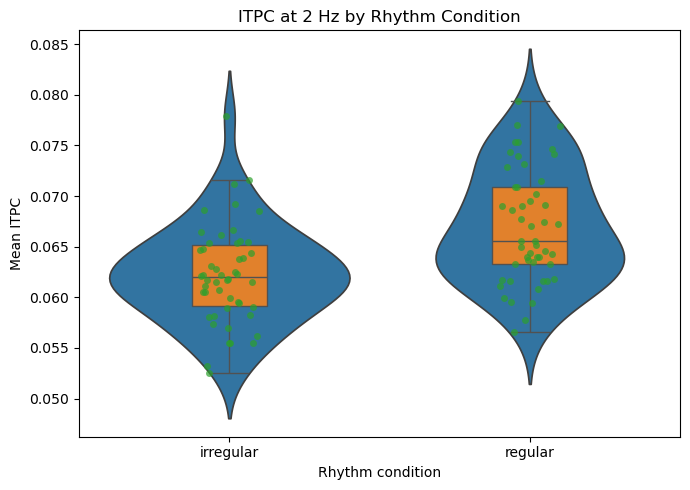

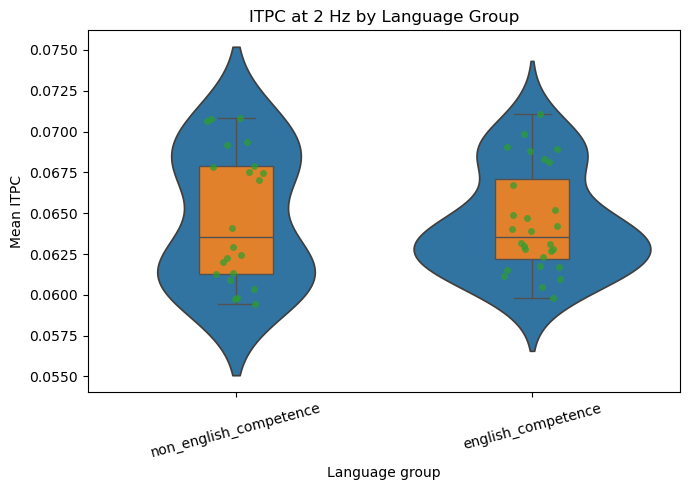

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make sure ITPC is numeric
df["itpc"] = pd.to_numeric(df["itpc"], errors="coerce")

# Optional: restrict to POEM / 2 Hz
plot_df = df[(df["frequency_name"] == "POEM") & (df["frequency_hz"] == 2.0)].copy()


# -----------------------------------
# Plot 1: ITPC by rhythm condition
# -----------------------------------

# Average within participant first
rhythm_df = plot_df.groupby(["participant", "rhythm_condition"], as_index=False)[
    "itpc"
].mean()

plt.figure(figsize=(7, 5))

sns.violinplot(data=rhythm_df, x="rhythm_condition", y="itpc", inner=None)

sns.boxplot(
    data=rhythm_df, x="rhythm_condition", y="itpc", width=0.25, showfliers=False
)

sns.stripplot(data=rhythm_df, x="rhythm_condition", y="itpc", jitter=True, alpha=0.7)

plt.xlabel("Rhythm condition")
plt.ylabel("Mean ITPC")
plt.title("ITPC at 2 Hz by Rhythm Condition")
plt.tight_layout()
plt.show()


# -----------------------------------
# Plot 2: ITPC by language group
# -----------------------------------

# One mean per participant
language_df = plot_df.groupby(["participant", "language_group"], as_index=False)[
    "itpc"
].mean()

plt.figure(figsize=(7, 5))

sns.violinplot(data=language_df, x="language_group", y="itpc", inner=None)

sns.boxplot(
    data=language_df, x="language_group", y="itpc", width=0.25, showfliers=False
)

sns.stripplot(data=language_df, x="language_group", y="itpc", jitter=True, alpha=0.7)

plt.xlabel("Language group")
plt.ylabel("Mean ITPC")
plt.title("ITPC at 2 Hz by Language Group")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()